In [1]:
import os

### to export libLLVM path
os.environ['DRJIT_LIBLLVM_PATH'] = "/home/aizi0357/environments/sionna_v0/lib/libLLVM-20.so"
os.environ["LD_LIBRARY_PATH"] = "$LD_LIBRARY_PATH:/home/aizi0357/environments/sionna_v0/lib/"

gpu_num = "" # Use "" to use the CPU
os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import sionna

resolution = [480,320] # increase for higher quality of renderings

# Allows to exit cell execution in Jupyter
class ExitCell(Exception):
    def _render_traceback_(self):
        pass

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("gpus:", gpus)

if gpu_num and gpus:
    print(f"Using GPU {gpu_num}")
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
else:
	print("Using CPU")

tf.get_logger().setLevel('ERROR')

tf.random.set_seed(1) # Set global random seed for reproducibility


import matplotlib.pyplot as plt
import numpy as np
import time

# Import Sionna RT components
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, Camera

E0000 00:00:1774964314.129872 3869308 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774964314.133761 3869308 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774964314.142844 3869308 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774964314.142859 3869308 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774964314.142861 3869308 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774964314.142863 3869308 computation_placer.cc:177] computation placer already registered. Please check linka

gpus: []
Using CPU


In [2]:
tx_dist = 100.0  # far-field 
num_points = 360

dtype = tf.complex128
rdtype = tf.float64

scene = load_scene(sionna.rt.scene.low_poly_car_i_miev, dtype)

num_edges: tf.Tensor(0, shape=(), dtype=int32)
num_wedges: 204


In [3]:
def get_circle_points(theta_arr, p1, p2):
	res = np.zeros((len(theta_arr), 3))
	res[:, 0] = p1[0] * np.cos(theta_arr) + p2[0] * np.sin(theta_arr)
	res[:, 1] = p1[1] * np.cos(theta_arr) + p2[1] * np.sin(theta_arr)
	res[:, 2] = p1[2] * np.cos(theta_arr) + p2[2] * np.sin(theta_arr)

	return res

pol = 'VV' # VV or HH

source_point = np.array([0.0, 30.0, 0.6])

circle_radius = 20.0  # 5, 10, 15, 20
receivers_z = 0.601  # 0.601, 0.9, 1.2, 1.5

theta_arr = np.linspace(0.0*np.pi, 2.0*np.pi, 360, endpoint=False)

circle_p1 = np.array([0, 1, 0]) * circle_radius
circle_p2 = np.array([1, 0, 0])  * circle_radius
receive_points = get_circle_points(theta_arr, circle_p1, circle_p2)
receive_points[:, 2] = receivers_z

In [4]:
scene.tx_array = PlanarArray(num_rows=1,
							 num_cols=1,
							 vertical_spacing=0.5,
							 horizontal_spacing=0.5,
							 pattern="iso",
							 polarization=pol[0],
							 dtype=dtype)

scene.rx_array = PlanarArray(num_rows=1,
							 num_cols=1,
							 vertical_spacing=0.5,
							 horizontal_spacing=0.5,
							 pattern="iso",
							 polarization=pol[1],
							 dtype=dtype)

fc = 2e9
lamda = 3e8 / fc

scene.frequency = fc
scene.synthetic_array = True 

scene.remove("tx")
for i in range(len(receive_points)):
	scene.remove(f"rx_{i}")


tx = Transmitter(name="tx", position=source_point, dtype=dtype) 
scene.add(tx)
for i in range(len(receive_points)):
	rx = Receiver(name=f"rx_{i}", position=receive_points[i], dtype=dtype)
	scene.add(rx)

coef_nf = coef_nf = 377 * 6.28 / (lamda)

In [6]:
em_sc_filename = './mlfmm_data/low_poly_car/sc_220.efe'
em_tot_filename = './mlfmm_data/low_poly_car/tot_220.efe'

def read_efe_file(filename, circle_radius, receivers_z):
	em = []
	with open(filename) as f:
		for i, line in enumerate(f):
			if i <= 16:
				continue

			a = line.split()
			if abs(float(a[2]) - receivers_z) > 1e-2:
				continue
			if abs(float(a[0]) - circle_radius) > 1e-2:
				continue

			_em = float(a[7]) + 1j*float(a[8])
			em.append(_em)

	em = np.array(em[::-1])
	em = np.concatenate((em[270:], em[:270]), axis=0)

	return em

em_sc = read_efe_file(em_sc_filename, circle_radius, receivers_z)
em_tot = read_efe_file(em_tot_filename, circle_radius, receivers_z)
em_sc.shape, em_tot.shape

((360,), (360,))

In [7]:
from sionna.rt.objects_geometry import ObjectsGeometry

car_obj_names = list(scene.objects.keys())

obj_geom = ObjectsGeometry(scene._solver_paths)
obj_geom.is_table_gfi = True
obj_geom.is_vertex_diffraction = True
obj_geom.is_double_diffraction = True
obj_geom.init_objects(car_obj_names, [None]*len(car_obj_names))

scene._solver_paths.vertex_diffraction.set_objects_geometry(obj_geom)
scene._solver_paths.double_diffraction.set_objects_geometry(obj_geom)

num vertices: 112


In [8]:
# for scattered field

def get_field_los_full(tx_pos, rx_poses):
	dist = np.linalg.norm(tx_pos - rx_poses, axis=1)
	field = 1.0 / dist / (4 * 3.141592653589793) * lamda 
	return field

field_los_full = get_field_los_full(source_point, receive_points)

paths = scene.compute_paths(max_depth=1,
							method="exhaustive",
							num_samples=1e6,
							los = True,
							reflection = False,
							diffraction = False,
							vertex_diffraction = False)

a, tau = paths.cir()
# tau = tau[0,:,0,0].numpy()
path_amplitudes = a[0,:,0,0,0,:,0]
receiver_amplitudes_los = np.abs(np.sum(path_amplitudes, axis=1)) #/ lamda

los_line = np.where(receiver_amplitudes_los <= 1e-6)[0][0], np.where(receiver_amplitudes_los <= 1e-6)[0][-1]
field_los_full = 1.0 * np.where(receiver_amplitudes_los <= 0.0, field_los_full, receiver_amplitudes_los) + 1e-8

if pol == 'VV':
	field_los_full = -field_los_full
	
los_line

(np.int64(172), np.int64(188))

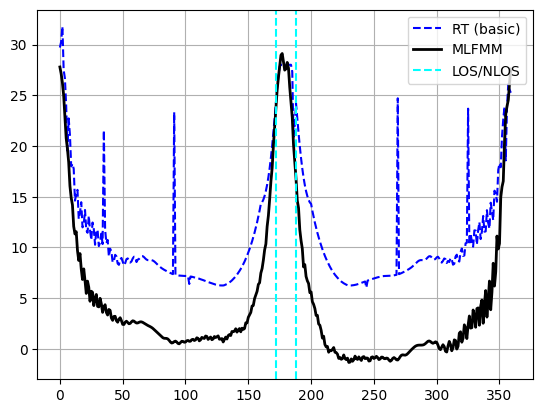

In [9]:
paths = scene.compute_paths(max_depth=1,
							method="exhaustive",
							num_samples=1e6,
							los = True,
							reflection = True,
							diffraction = True,
							vertex_diffraction = False,
							double_diffraction=False)

a, tau = paths.cir()
path_amplitudes = a[0,:,0,0,0,:,0]

tmp1 = np.sum(path_amplitudes, axis=1) + field_los_full
	
rt_basic = np.abs(tmp1) / lamda
	
plt.plot(20*np.log10(coef_nf*rt_basic), 'b--', label="RT (basic)")
plt.plot(20*np.log10(np.abs(em_sc)), 'k', label='MLFMM', linewidth=2)
plt.axvline(x=57.3*theta_arr[los_line[0]], color='cyan', linestyle='--', label='LOS/NLOS')
plt.axvline(x=57.3*theta_arr[los_line[1]], color='cyan', linestyle='--')
# plt.title("Scattering: RT")
plt.grid()
plt.legend()

/home/aizi0357/projects/sionna_reflectivity_public/sionna/rt/double_diffraction.py:2963: RuntimeWarning: divide by zero encountered in divide
  spreading_factor = np.sqrt(r1) / (np.sqrt(l * r2) * np.sqrt(r1 + l + r2))


Text(0, 0.5, '|E_sc| [dB]')

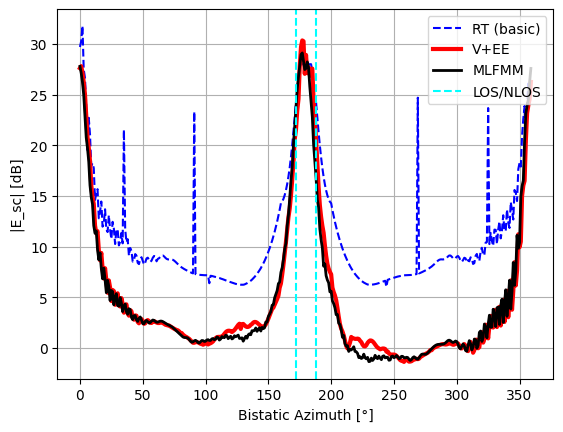

In [10]:
scene._solver_paths.double_diffraction.is_wedge_vertex = True
scene._solver_paths.double_diffraction.is_vertex_wedge = True
scene._solver_paths.double_diffraction.is_vertex_vertex = True

paths = scene.compute_paths(max_depth=1,
							method="exhaustive",
							num_samples=1e6,
							los = True,
							reflection = True,
							diffraction = True,
							vertex_diffraction = True,
							double_diffraction = True)

a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]

tmp1 = np.sum(path_amplitudes, axis=1) + field_los_full
	
rt_dd = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef_nf*rt_basic), 'b--', label="RT (basic)")
plt.plot(20*np.log10(coef_nf*rt_dd), 'r', label="V+EE", linewidth=3)
plt.plot(20*np.log10(np.abs(em_sc)), 'k', label='MLFMM', linewidth=2)

plt.axvline(x=57.3*theta_arr[los_line[0]], color='cyan', linestyle='--', label='LOS/NLOS')
plt.axvline(x=57.3*theta_arr[los_line[1]], color='cyan', linestyle='--')
# plt.xlim(130, 230)
plt.grid()
plt.legend()
plt.xlabel('Bistatic Azimuth [°]')
plt.ylabel('|E_sc| [dB]')

/tmp/ipykernel_3869308/2239076968.py:19: RuntimeWarning: divide by zero encountered in log10
  plt.plot(20*np.log10(coef_nf*rt_vd), '--b', label="V")


Text(0, 0.5, '|E_tot| [dB]')

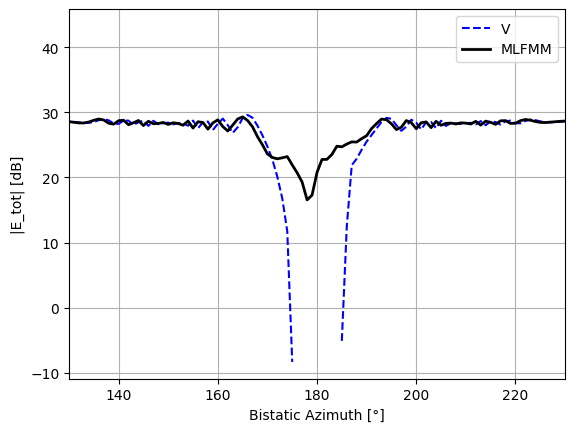

In [11]:
# Total
paths = scene.compute_paths(max_depth=1,
							method="exhaustive",
							num_samples=1e6,
							los = True,
							reflection = True,
							diffraction = True,
							vertex_diffraction = True,
							double_diffraction=False)

a, tau = paths.cir()
path_amplitudes = a[0,:,0,0,0,:,0]


tmp1 = np.sum(path_amplitudes, axis=1)
	
rt_vd = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef_nf*rt_vd), '--b', label="V")
plt.plot(20*np.log10(np.abs(em_tot)), 'k', label='MLFMM', linewidth=2)
plt.xlim(130, 230)
plt.grid()
plt.legend()
plt.xlabel('Bistatic Azimuth [°]')
plt.ylabel('|E_tot| [dB]')

/tmp/ipykernel_3869308/3210441048.py:26: RuntimeWarning: divide by zero encountered in log10
  plt.plot(20*np.log10(coef_nf*rt_vd), 'b--', label="V")


Text(0, 0.5, '|E_tot| [dB]')

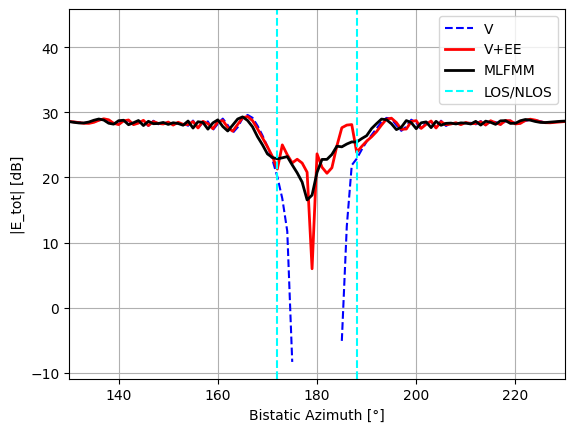

In [12]:
scene._solver_paths.double_diffraction.is_wedge_vertex = False
scene._solver_paths.double_diffraction.is_vertex_wedge = False
scene._solver_paths.double_diffraction.is_vertex_vertex = False

paths = scene.compute_paths(max_depth=1,
							method="exhaustive",
							num_samples=1e6,
							los = True,
							reflection = True,
							diffraction = True,
							vertex_diffraction = True,
							double_diffraction = True)

a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]

tmp1 = np.sum(path_amplitudes, axis=1)
	
rt_dd = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef_nf*rt_vd), 'b--', label="V")
plt.plot(20*np.log10(coef_nf*rt_dd), 'r', label="V+EE", linewidth=2)
plt.plot(20*np.log10(np.abs(em_tot)), 'k', label='MLFMM', linewidth=2)

plt.axvline(x=57.3*theta_arr[los_line[0]], color='cyan', linestyle='--', label='LOS/NLOS')
plt.axvline(x=57.3*theta_arr[los_line[1]], color='cyan', linestyle='--')
plt.xlim(130, 230)
plt.grid()
plt.legend()
plt.xlabel('Bistatic Azimuth [°]')
plt.ylabel('|E_tot| [dB]')

/tmp/ipykernel_3869308/617121506.py:32: RuntimeWarning: divide by zero encountered in log10
  plt.plot(20*np.log10(coef_nf*rt_vd), 'b--', label="V")


Text(0, 0.5, '|E_tot| [dB]')

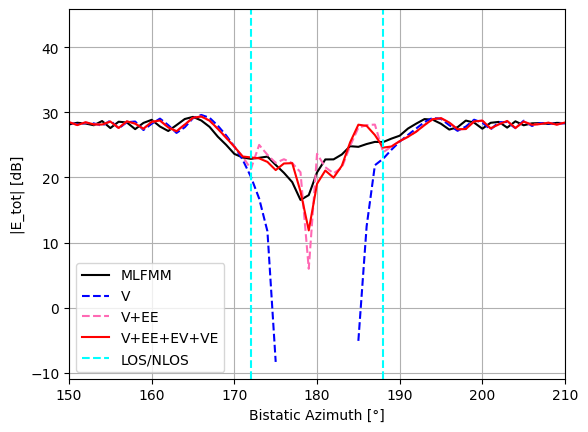

In [13]:
# scene._solver_paths.double_diffraction.is_only_coplanar = True
# scene._solver_paths.double_diffraction.is_wedge_wedge = True 
# scene._solver_paths.double_diffraction.is_ww_analytical = True
# scene._solver_paths.double_diffraction.is_ww_analytical_with_double_tilda = True
scene._solver_paths.double_diffraction.is_wedge_vertex = True
scene._solver_paths.double_diffraction.is_vertex_wedge = True
scene._solver_paths.double_diffraction.is_vw_reversed_compute_fields = True
scene._solver_paths.double_diffraction.close_2_transition_eps = 0.9

paths = scene.compute_paths(max_depth=1,
							method="exhaustive",
							num_samples=1e6,
							los = True,
							reflection = True,
							diffraction = True,
							vertex_diffraction = True,
							double_diffraction = True)

a, tau = paths.cir()

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]

tmp1 = np.sum(path_amplitudes, axis=1)
	
rt_all_dd = np.abs(tmp1) / lamda

# plt.plot(20*np.log10(coef_nf*receiver_amplitudes_vd), label="V", linestyle='--')
plt.plot(20*np.log10(np.abs(em_tot)), 'k', label='MLFMM')
plt.plot(20*np.log10(coef_nf*rt_vd), 'b--', label="V")
plt.plot(20*np.log10(coef_nf*rt_dd),  color='#ff69b4', linestyle='--', label="V+EE")
plt.plot(20*np.log10(coef_nf*rt_all_dd), 'r', label="V+EE+EV+VE")
plt.axvline(x=57.3*theta_arr[los_line[0]], color='cyan', linestyle='--', label='LOS/NLOS')
plt.axvline(x=57.3*theta_arr[los_line[1]], color='cyan', linestyle='--')
# plt.ylim(10)
plt.xlim(150, 210)
plt.grid()
plt.legend()
plt.xlabel('Bistatic Azimuth [°]')
plt.ylabel('|E_tot| [dB]')